[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/agent-memory.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239417-lesson-7-agent-with-memory)

# Agent memory

## 回顧

先前，我們建立了一個 agent，它可以：

* `act` —— 讓模型呼叫特定的 tool
* `observe` —— 把 tool 的輸出回傳給模型
* `reason` —— 讓模型針對 tool 的輸出進行推理，以決定下一步要做什麼（例如呼叫另一個 tool，或直接回覆）

![Screenshot 2024-08-21 at 12.45.32 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab7453080e6802cd1703_agent-memory1.png)

## 目標

現在，我們要透過引入 memory 來擴充我們的 agent。

In [ ]:
# %%capture --no-stderr
# %pip install --quiet -U langchain_openai langchain_core langgraph langgraph-prebuilt

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

我們會用 [LangSmith](https://docs.langchain.com/langsmith/home) 來做 [tracing](https://docs.langchain.com/langsmith/observability-concepts)。

In [3]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

這延續了我們先前所做的內容。

In [4]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOpenAI(model="gpt-4o")
llm_with_tools = llm.bind_tools(tools)

In [5]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

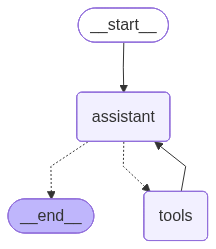

In [6]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## Memory

讓我們像之前一樣執行我們的 agent。

In [7]:
messages = [HumanMessage(content="Add 3 and 4.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_bp0nxSDpzWJKCq5zI838q0gy)
 Call ID: call_bp0nxSDpzWJKCq5zI838q0gy
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


現在，讓我們把它乘以 2！

In [8]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================

It seems like there is no provided number to multiply by 2. Could you please specify the number you'd like me to multiply?


我們並沒有保留一開始對話中那個 7 的記憶！

這是因為 [state 對單次 graph 執行而言是短暫的（transient）](https://github.com/langchain-ai/langgraph/discussions/352#discussioncomment-9291220)。

當然，這限制了我們進行多輪、可中斷對話的能力。

我們可以用 [persistence](https://docs.langchain.com/oss/python/langgraph/persistence) 來解決這個問題！

LangGraph 可以使用 checkpointer，在每一步之後自動儲存 graph state。

這個內建的 persistence 層給了我們 memory，讓 LangGraph 能夠從上一次 state 更新的地方繼續往下走。

最容易上手的 checkpointer 之一就是 `MemorySaver`，它是一個用來存放 Graph state 的記憶體內鍵值儲存（in-memory key-value store）。

我們只需要在編譯 graph 時加上一個 checkpointer，我們的 graph 就有 memory 了！

In [8]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)

當我們使用 memory 時，需要指定一個 `thread_id`。

這個 `thread_id` 會儲存我們這一整組 graph state。

這裡有一張示意圖：

* checkpointer 會在 graph 的每一步寫入 state
* 這些 checkpoint 會被存進一個 thread
* 我們未來可以用 `thread_id` 來存取那個 thread

![state.jpg](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e0e9f526b41a4ed9e2d28b_agent-memory2.png)


In [9]:
# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_MSupVAgej4PShIZs7NXOE6En)
 Call ID: call_MSupVAgej4PShIZs7NXOE6En
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


如果我們傳入相同的 `thread_id`，就可以從先前所記錄的 state checkpoint 繼續往下走！

在這個例子中，上面那段對話已經被捕捉在這個 thread 裡。

我們傳入的 `HumanMessage`（`"Multiply that by 2."`）會被附加到上面那段對話之後。

所以，模型現在知道 `that` 指的是 `The sum of 3 and 4 is 7.`。

In [10]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_MSupVAgej4PShIZs7NXOE6En)
 Call ID: call_MSupVAgej4PShIZs7NXOE6En
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_fWN7lnSZZm82tAg7RGeuWusO)
 Call ID: call_fWN7lnSZZm82tAg7RGeuWusO
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

The result of multipl

## Studio

**⚠️ 注意**

更新了 Studio，現在它可以在本機執行並透過你的瀏覽器存取。相較於影片中所示的桌面 App，這是執行 Studio 的建議方式。它現在改名為 _LangSmith Studio_，而非 _LangGraph Studio_。詳細的設定說明請見課程一開始的「Getting Setup」指南。你可以在[這裡](https://docs.langchain.com/langsmith/studio)找到 Studio 的說明，並在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)找到本機部署的具體細節。
若要啟動本機開發伺服器，請在你的終端機中、於本模組的 `/studio` 目錄下執行以下指令：

```
langgraph dev
```

你應該會看到以下輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

開啟你的瀏覽器，前往上面顯示的 **Studio UI** URL。
在 Studio 中載入 `agent`，它使用的是 `module-1/studio/langgraph.json` 中所設定的 `module-1/studio/agent.py`。